## Figure 1: math drop in proficiency

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [16]:

# read the data
df = pd.read_csv('new_sif_data_table_2024_25prelim_en_april2026.csv')

In [17]:
df.columns

Index(['Board Number', 'Board Name', 'Board Type', 'School Number',
       'School Name', 'School Type', 'School Special Condition Code',
       'School Level', 'School Language', 'Grade Range', 'Building Suite',
       'P.O. Box', 'Street', 'Municipality', 'City', 'Province', 'Postal Code',
       'Phone Number', 'Fax Number', 'School Website', 'Board Website',
       'Enrolment', 'Latitude', 'Longitude',
       'Percentage of Students Whose First Language Is Not English',
       'Percentage of Students Whose First Language Is Not French',
       'Percentage of Students Who Are New to Canada from a Non-English Speaking Country',
       'Percentage of Students Who Are New to Canada from a Non-French Speaking Country',
       'Percentage of Students Receiving Special Education Services',
       'Percentage of Students Identified as Gifted',
       'Percentage of Grade 3 Students Achieving the Provincial Standard in Reading',
       'Change in Grade 3 Reading Achievement Over Three Years

In [18]:
# preprocess data
g3_col =   'Percentage of Grade 3 Students Achieving the Provincial Standard in Mathematics'
g6_col = 'Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics'

df[g3_col]
df[g6_col]

0       NaN
1       48%
2       14%
3       41%
4       71%
       ... 
4938    75%
4939    NaN
4940    48%
4941    91%
4942    43%
Name: Percentage of Grade 6 Students Achieving the Provincial Standard in Mathematics, Length: 4943, dtype: object

In [19]:



# Convert to string, remove the '%' sign, and convert to numeric
df['g3_math'] = pd.to_numeric(df[g3_col].astype(str).str.replace('%', '', regex=False), errors='coerce')
df['g6_math'] = pd.to_numeric(df[g6_col].astype(str).str.replace('%', '', regex=False), errors='coerce')

# check
df['g3_math']

0        NaN
1       82.0
2       45.0
3       50.0
4       51.0
        ... 
4938    79.0
4939     NaN
4940    79.0
4941     NaN
4942    85.0
Name: g3_math, Length: 4943, dtype: float64

In [20]:


# overall prov avgs
prov_g3 = df['g3_math'].mean()
prov_g6 = df['g6_math'].mean()

# get board averages for the background lines
# dropping small boards (<20 schools) so it's not a noisy mess
boards = df.groupby('Board Name').agg({'g3_math':'mean', 'g6_math':'mean', 'School Number':'count'}).dropna()
boards = boards[boards['School Number'] > 20]

In [21]:
# check
boards

,g3_math,g6_math,School Number
Board Name,,,
Algoma DSB,51.041667,38.807692,45
Algonquin and Lakeshore CDSB,54.428571,42.384615,41
Avon Maitland DSB,67.466667,50.000000,46
Bluewater DSB,63.117647,39.676471,51
Brant Haldimand Norfolk CDSB,62.346154,40.384615,34
CDSB of Eastern Ontario,56.960000,41.961538,49
CS Viamonde,83.575000,76.225000,73
CS catholique MonAvenir,72.500000,61.488372,76
CS public du Grand Nord de l'Ontario,61.375000,43.833333,26


In [ ]:
# setup fig
fig, ax = plt.subplots(figsize=(9, 7), facecolor='#FAFAFA', dpi=300)
ax.set_facecolor('#FAFAFA')

# draw faint lines for all the boards
for index, row in boards.iterrows():
    ax.plot([1, 2], [row['g3_math'], row['g6_math']], color='#B0B0B0', alpha=0.3, linewidth=1.5, zorder=1)

# main line for provincial avg
ax.plot([1, 2], [prov_g3, prov_g6], color='#007FA3', marker='o', markersize=12, linewidth=4, zorder=5)

# labels right next to the points (no legend needed)
ax.text(0.95, prov_g3, f"Provincial Avg:\n{prov_g3:.1f}%", color='#007FA3', fontweight='bold', fontsize=11, ha='right', va='center')
ax.text(2.05, prov_g6, f"Provincial Avg:\n{prov_g6:.1f}%", color='#007FA3', fontweight='bold', fontsize=11, ha='left', va='center')

# x labels
ax.text(1.0, 85, "Grade 3 Math", fontweight='bold', fontsize=13, ha='center', va='bottom', color='#333333')
ax.text(2.0, 85, "Grade 6 Math", fontweight='bold', fontsize=13, ha='center', va='bottom', color='#333333')

# fake vertical grid lines to ground the points
ax.axvline(1, color='#DDDDDD', linewidth=1, zorder=0)
ax.axvline(2, color='#DDDDDD', linewidth=1, zorder=0)

# clean up y axis
ax.set_ylim(20, 90)
ax.set_xlim(0.6, 2.4)
ax.set_yticks([20, 30, 40, 50, 60, 70, 80])
ax.set_yticklabels([f"{tick}%" for tick in [20, 30, 40, 50, 60, 70, 80]], color='#777777', fontsize=10)

# drop the outer box
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# hide standard ticks entirely
ax.tick_params(axis='both', which='both', length=0)
ax.set_xticks([])

# light horizontal grid so you can read the values
ax.yaxis.grid(True, color='#EEEEEE', linestyle='-', linewidth=1, zorder=0)

# titles and text
plt.suptitle("The Middle-Elementary Math Bottleneck", fontsize=18, fontweight='bold', x=0.1, y=0.98, ha='left', color='#222222')
ax.set_title("Ontario students experience a significant drop in mathematical proficiency between Grade 3 and Grade 6.\nGrey lines represent individual school board averages.", 
             fontsize=11, color='#555555', loc='left', pad=20)

# draw attention to the actual drop
drop_diff = prov_g3 - prov_g6
ax.annotate(f"A {drop_diff:.1f}% drop\nin provincial\nproficiency", 
            xy=(1.5, (prov_g3 + prov_g6)/2), 
            xytext=(1.5, 75),
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='#007FA3',
            arrowprops=dict(arrowstyle="->", color='#007FA3', lw=1.5, connectionstyle="arc3"))

# footer 
fig.text(0.1, 0.02, "Data: Ontario School Information Framework (SIF) 2024-2025 | Analysis of boards with >20 schools", fontsize=9, color='#888888', ha='left')

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.93])
plt.savefig('math_dropoff_python.png')

## Figure 2

/var/folders/bm/zz3zwwtj491ggdvwhnvk_wyr0000gn/T/ipykernel_29786/176432708.py:67: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(top_10['Board Name'], color='#444444', fontweight='bold')


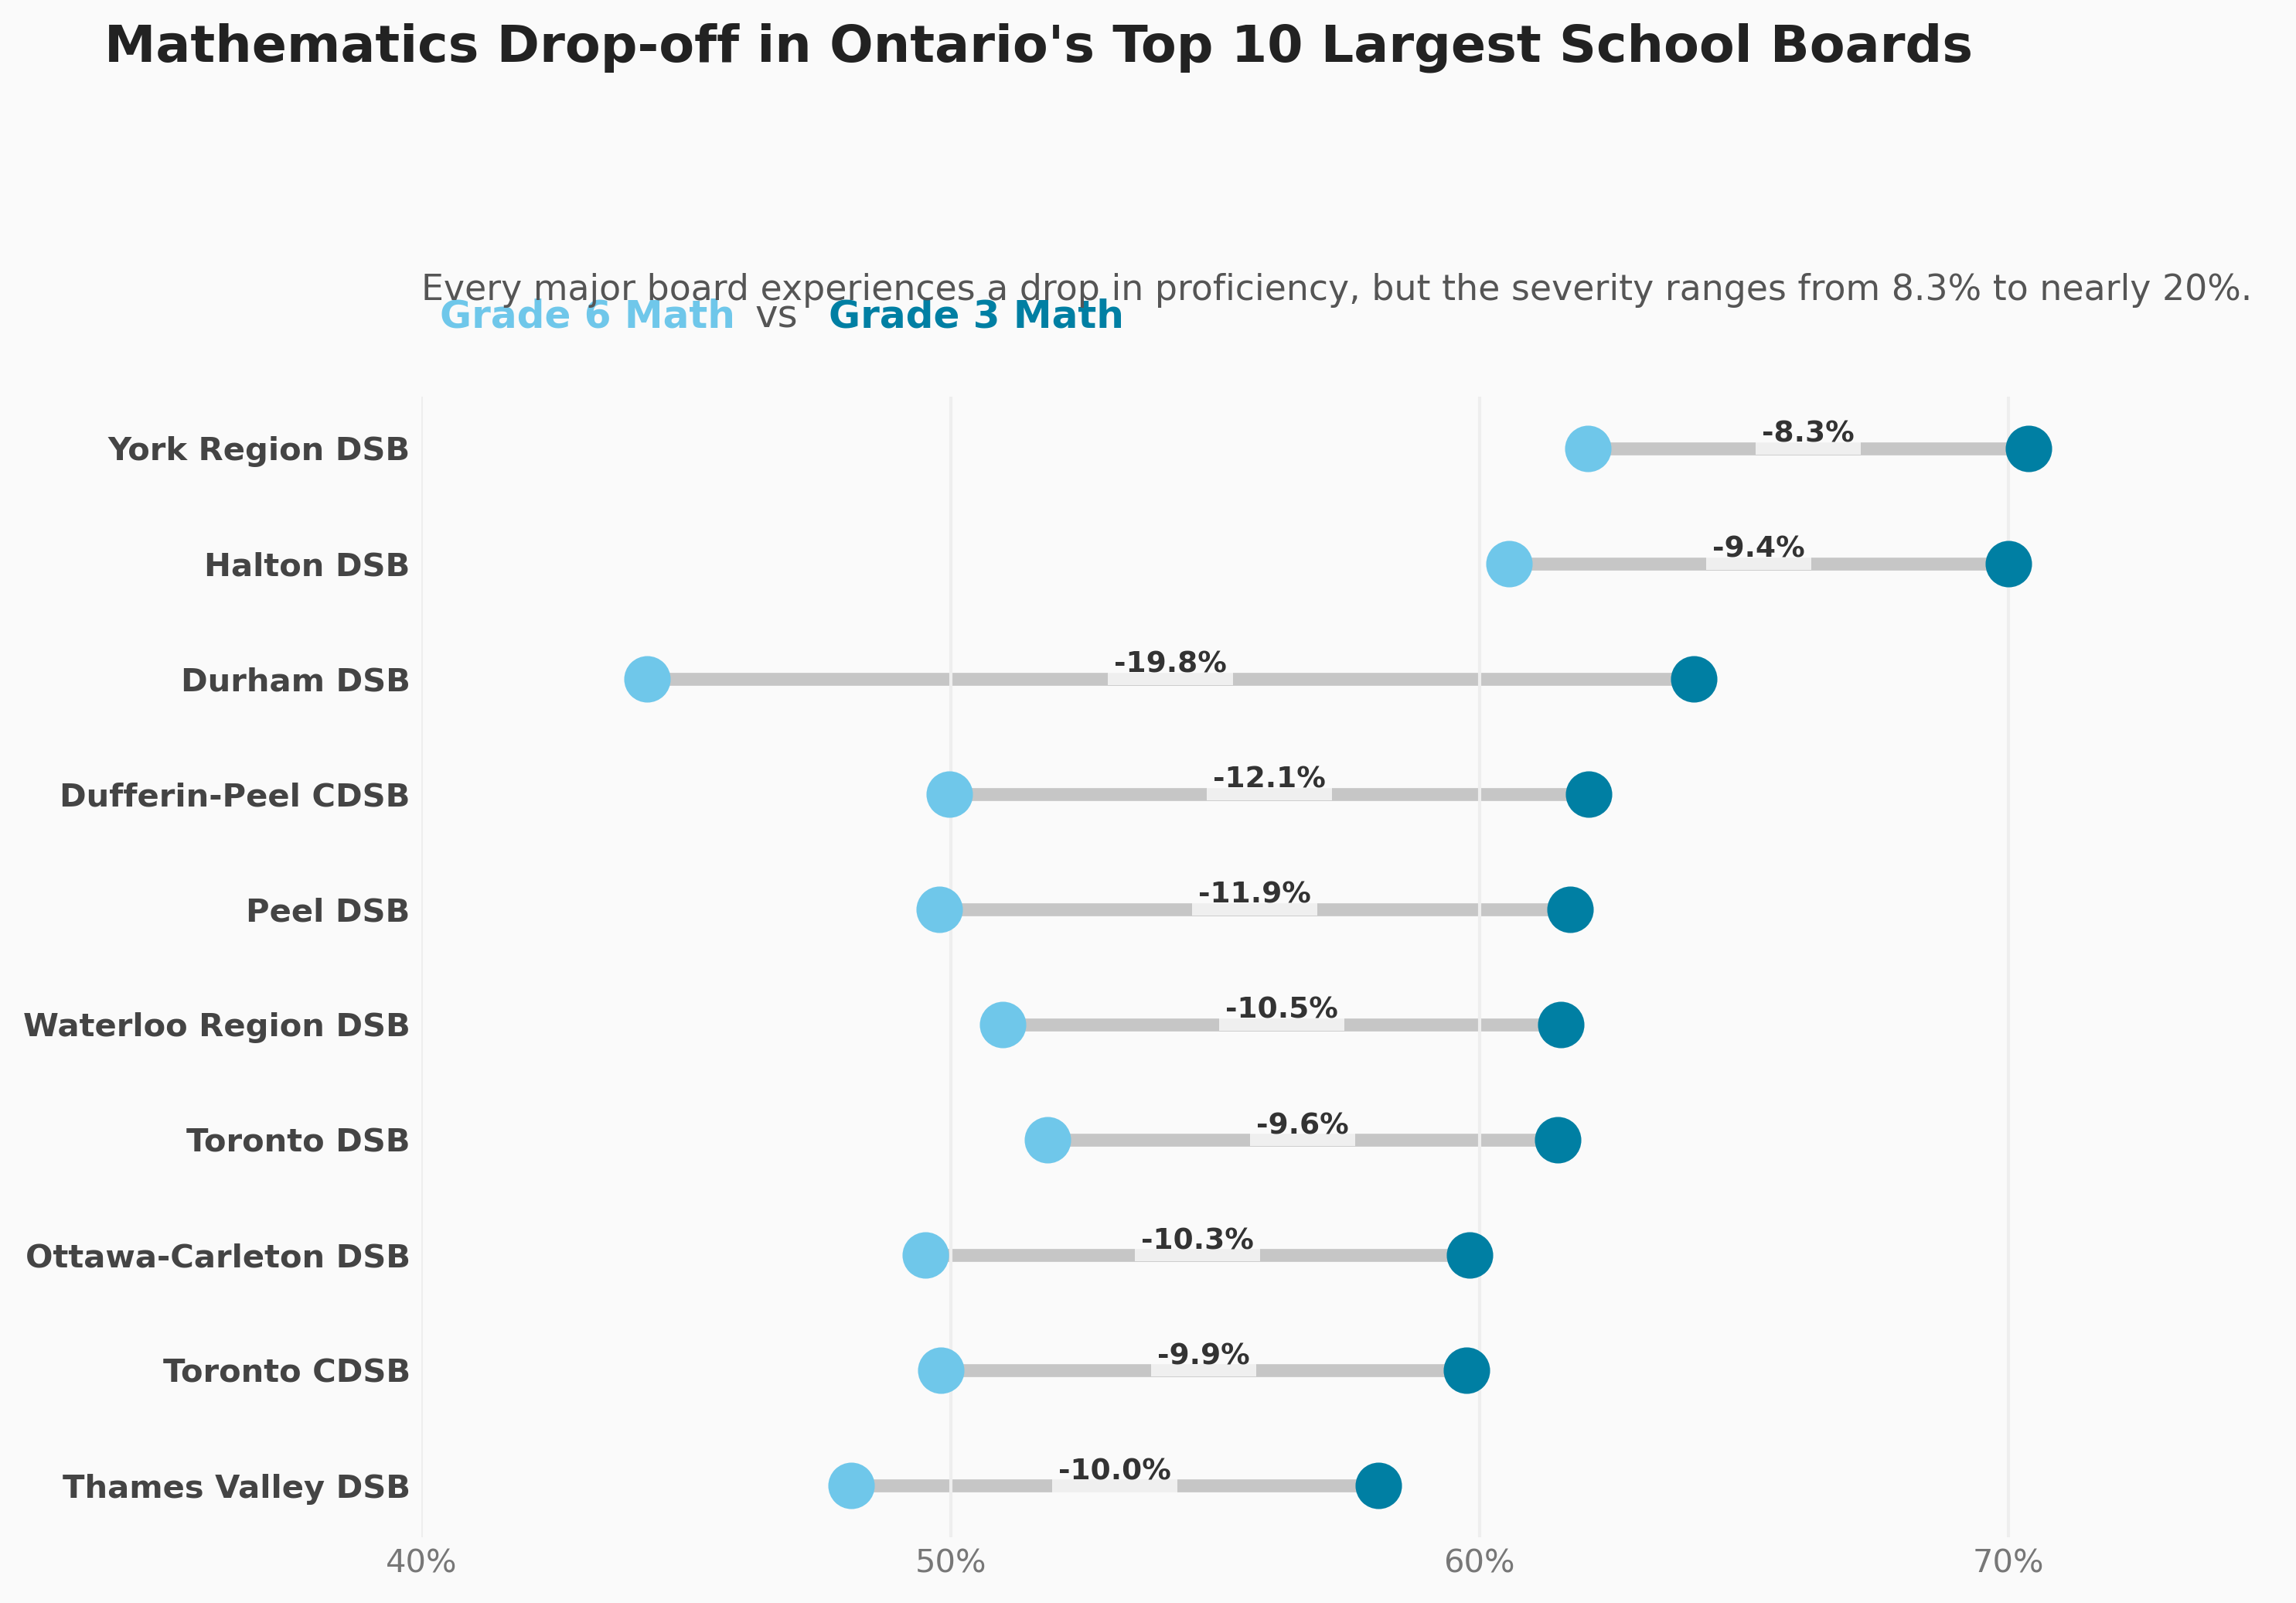

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# find top 10 largest boards
boards = df.groupby('Board Name').agg({
    'g3_math': 'mean', 
    'g6_math': 'mean', 
    'School Number': 'count'
}).dropna().reset_index()

top_10 = boards.nlargest(10, 'School Number').copy()

# Sort by Grade 3 Math score (ascending so the highest is at the top of the y-axis)
top_10 = top_10.sort_values(by='g3_math', ascending=True)

# 3. Setup the plot
fig, ax = plt.subplots(figsize=(10, 7), facecolor='#FAFAFA', dpi=300)
ax.set_facecolor('#FAFAFA')

# 4. Draw the dumbbell shapes
# Draw the horizontal connecting lines
ax.hlines(y=top_10['Board Name'], 
          xmin=top_10['g6_math'], 
          xmax=top_10['g3_math'], 
          color='#B0B0B0', alpha=0.7, linewidth=4, zorder=1)

# Draw the points (Green for Grade 3 starting point, Red for Grade 6 ending point)
ax.scatter(top_10['g3_math'], top_10['Board Name'], color='#007FA3', s=180, zorder=2) 
ax.scatter(top_10['g6_math'], top_10['Board Name'], color='#6FC7EA', s=180, zorder=2) 

# 5. Direct labeling for the severity of the drop
for i, row in top_10.iterrows():
    drop_val = row['g3_math'] - row['g6_math']
    mid_point = (row['g3_math'] + row['g6_math']) / 2
    
    # Place text hovering slightly above the middle of the line
    ax.text(mid_point, row['Board Name'], f"-{drop_val:.1f}%", 
            color='#333333', fontsize=9, fontweight='bold', ha='center', va='bottom', 
            bbox=dict(facecolor='#FAFAFA', edgecolor='none', pad=2, alpha=0.8))

# 6. Aesthetics and Chart Junk Removal
# Create a custom legend using colored text at the top instead of a detached box
ax.text(0.01, 1.06, "Grade 6 Math", color='#6FC7EA', fontweight='bold', fontsize=12, transform=ax.transAxes)
ax.text(0.18, 1.06, "vs", color='#555555', fontsize=12, transform=ax.transAxes)
ax.text(0.22, 1.06, "Grade 3 Math", color='#007FA3', fontweight='bold', fontsize=12, transform=ax.transAxes)

plt.suptitle("Mathematics Drop-off in Ontario's Top 10 Largest School Boards", 
             fontsize=16, fontweight='bold', x=0.05, y=0.98, ha='left', color='#222222')
ax.set_title("Every major board experiences a drop in proficiency, but the severity ranges from 8.3% to nearly 20%.", 
             fontsize=11, color='#555555', loc='left', pad=30)

# X-axis formatting
ax.set_xlim(40, 75)
ax.set_xticks([40, 50, 60, 70])
ax.set_xticklabels(['40%', '50%', '60%', '70%'], color='#777777')
ax.xaxis.grid(True, color='#EEEEEE', linestyle='-', linewidth=1, zorder=0)

# Remove all bounding box spines
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
    
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('')

# Bold the y-axis labels
ax.set_yticklabels(top_10['Board Name'], color='#444444', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('top10_math_dropoff_python.png')